## **Setup and Imports**

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_palette("husl")

# Add path to access modules
code_path = '/kaggle/input/datasets/imadsaeed123/vehicle-sale-data/Vehicle Sales Data/code'
sys.path.insert(0, code_path)
sys.path.insert(0, os.path.join(code_path, 'Script'))
sys.path.insert(0, os.path.join(code_path, 'modules'))

# Import the Classification class
from Sklearn_Classification_models import ClassificationModels

print(" \u2713 Setup complete!")

 ✓ Setup complete!


## **Initialize Trainer (Loads Data)**

In [2]:
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('tornado').setLevel(logging.ERROR)
# Path to your CSV file
file_path = '/kaggle/input/datasets/imadsaeed123/vehicle-sale-data/Vehicle Sales Data/archive/car_prices.csv'

# Create trainer instance (automatically loads and preprocesses data for classification)
trainer = ClassificationModels(file_path)

print("\n  Trainer initialized! Data is ready for classification.")

CLASSIFICATION MODELS TRAINING
Ὄ2 Loading preprocessed data...
✅ Loaded 558,837 rows and 16 columns

STEP 1: CLEANING DATA
✅ Dropped columns: ['vin']
✅ Cleaned transmission column - fixed invalid values
⚠️ Dropped saledate (could not parse)

STEP 2: HANDLING MISSING VALUES
⚠️ Missing values found: {'make': np.int64(10301), 'model': np.int64(10399), 'trim': np.int64(10651), 'body': np.int64(13195), 'condition': np.int64(11820), 'odometer': np.int64(94), 'color': np.int64(749), 'interior': np.int64(749), 'mmr': np.int64(38), 'sellingprice': np.int64(12)}
✅ Filled transmission missing values with 'automatic'
✅ Filled make missing values with mode: 'Ford'
✅ Filled model missing values with mode: 'Altima'
✅ Filled trim missing values with mode: 'Base'
✅ Filled body missing values with mode: 'Sedan'
✅ Filled color missing values with mode: 'black'
✅ Filled interior missing values with mode: 'black'
✅ Filled condition missing values with median: 35.00
✅ Filled odometer missing values with med

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7e760c84ae90>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 268-269: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^

✅ Scaled 11 numeric features

PREPARING CLASSIFICATION DATA


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 123-124: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/zmq/eventloop/zmqstream.py", line 551, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 120, in _handle_event
    event_f()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to

## **Train Logistic Regression**

In [3]:
#  Train Logistic Regression
model_lr, metrics_lr = trainer.train_logistic_regression(max_iter=1000)
print("\n \u2713 Logistic Regression training complete!")


 Training Logistic Regression

ὌA Results:
   Training Accuracy: 0.8997
   Test Accuracy: 0.8993
   Test Precision: 0.8986
   Test Recall: 0.8993
   Test F1-Score: 0.8988
   Training time: 3.84 seconds

ὌA Confusion Matrix:
                 Predicted
                 Low  Med  High
      Actual Low  34700  2973    77
            Med  3318  30603  2897
            High   10  1979  35211
ὋE Model saved: logistic_regression.pkl
ὍD Classification report saved: logistic_regression_classification_report.csv
ὍD Predictions saved: logistic_regression_predictions.csv

 ✓ Logistic Regression training complete!


## **Train KNN Classifier**

In [4]:
#  Train K-Neighbors Classifier
model_knn, metrics_knn = trainer.train_knn_classifier(n_neighbors=5)
print("\n \u2713 KNN Classifier training complete!")


 Training K-Neighbors Classifier (k=5)

ὌA Results:
   Training Accuracy: 0.9251
   Test Accuracy: 0.8912
   Test Precision: 0.8922
   Test Recall: 0.8912
   Test F1-Score: 0.8916
   Training time: 0.12 seconds

ὌA Confusion Matrix:
                 Predicted
                 Low  Med  High
      Actual Low  34266  3444    40
            Med  3130  31321  2367
            High   44  3131  34025
ὋE Model saved: knn_classifier.pkl
ὍD Classification report saved: knn_classifier_classification_report.csv
ὍD Predictions saved: knn_classifier_predictions.csv

 ✓ KNN Classifier training complete!


## **Train Decision Tree Classifier**

In [5]:
#  Train Decision Tree Classifier
model_dt, metrics_dt = trainer.train_decision_tree_classifier(max_depth=20)
print("\n \u2713 Decision Tree Classifier training complete!")


 Training Decision Tree Classifier (max_depth=20)

ὌA Results:
   Training Accuracy: 0.9813
   Test Accuracy: 0.9072
   Test Precision: 0.9077
   Test Recall: 0.9072
   Test F1-Score: 0.9074
   Training time: 6.86 seconds

ὌA Confusion Matrix:
                 Predicted
                 Low  Med  High
      Actual Low  34779  2930    41
            Med  2623  31998  2197
            High   51  2528  34621
ὋE Model saved: decision_tree_classifier.pkl
ὍD Classification report saved: decision_tree_classification_report.csv
ὍD Predictions saved: decision_tree_predictions.csv

ὐD Top 10 Features (Decision Tree):
      mmr: 0.8550
      condition: 0.0346
      odometer: 0.0216
      seller_encoded: 0.0185
      state_encoded: 0.0122
      model_encoded: 0.0119
      trim_encoded: 0.0105
      color_encoded: 0.0080
      year: 0.0080
      make_encoded: 0.0066
ὌA Feature importance saved: decision_tree_feature_importance.csv

 ✓ Decision Tree Classifier training complete!


## **Train Random Forest Classifier**

In [6]:
#  Train Random Forest Classifier
model_rf, metrics_rf = trainer.train_random_forest_classifier(n_estimators=100)
print("\n \u2713 Random Forest Classifier training complete!")


 Training Random Forest Classifier (n_estimators=100)

ὌA Results:
   Training Accuracy: 1.0000
   Test Accuracy: 0.9280
   Test Precision: 0.9284
   Test Recall: 0.9280
   Test F1-Score: 0.9282
   Training time: 50.05 seconds

ὌA Confusion Matrix:
                 Predicted
                 Low  Med  High
      Actual Low  35367  2350    33
            Med  1940  33139  1739
            High    5  1979  35216
ὋE Model saved: random_forest_classifier.pkl
ὍD Classification report saved: random_forest_classification_report.csv
ὍD Predictions saved: random_forest_predictions.csv

ὐD Top 10 Features (Random Forest):
      mmr: 0.4161
      odometer: 0.1171
      year: 0.0941
      model_encoded: 0.0923
      seller_encoded: 0.0889
      trim_encoded: 0.0501
      condition: 0.0457
      body_encoded: 0.0276
      make_encoded: 0.0222
      state_encoded: 0.0196
ὌA Feature importance saved: random_forest_feature_importance.csv

 ✓ Random Forest Classifier training complete!


## **Train Naive Bayes Classifier**

In [7]:
#  Train Gaussian Naive Bayes
model_nb, metrics_nb = trainer.train_naive_bayes()
print("\n  \u2713 Naive Bayes Classifier training complete!")


 Training Gaussian Naive Bayes

ὌA Results:
   Training Accuracy: 0.7919
   Test Accuracy: 0.7907
   Test Precision: 0.8303
   Test Recall: 0.7907
   Test F1-Score: 0.7951
   Training time: 0.34 seconds

ὌA Confusion Matrix:
                 Predicted
                 Low  Med  High
      Actual Low  30112  7254   384
            Med  2738  32951  1129
            High  323  11561  25316
ὋE Model saved: naive_bayes.pkl
ὍD Classification report saved: naive_bayes_classification_report.csv
ὍD Predictions saved: naive_bayes_predictions.csv

  ✓ Naive Bayes Classifier training complete!


## **Train Gradient Boosting Classifier**

In [8]:
# Train Gradient Boosting Classifier
model_gb, metrics_gb = trainer.train_gradient_boosting_classifier(n_estimators=100)
print("\n \u2713 Gradient Boosting Classifier training complete!")


 Training Gradient Boosting Classifier (n_estimators=100)

ὌA Results:
   Training Accuracy: 0.9281
   Test Accuracy: 0.9264
   Test Precision: 0.9267
   Test Recall: 0.9264
   Test F1-Score: 0.9265
   Training time: 421.83 seconds

ὌA Confusion Matrix:
                 Predicted
                 Low  Med  High
      Actual Low  35404  2318    28
            Med  2023  32912  1883
            High    4  1965  35231
ὋE Model saved: gradient_boosting_classifier.pkl
ὍD Classification report saved: gradient_boosting_classification_report.csv
ὍD Predictions saved: gradient_boosting_predictions.csv

ὐD Top 10 Features (Gradient Boosting):
      mmr: 0.9732
      condition: 0.0211
      seller_encoded: 0.0029
      year: 0.0015
      odometer: 0.0004
      model_encoded: 0.0004
      state_encoded: 0.0002
      trim_encoded: 0.0002
      body_encoded: 0.0001
      transmission_manual: 0.0000
ὌA Feature importance saved: gradient_boosting_feature_importance.csv

 ✓ Gradient Boosting Classifie

## **Compare All Models**

In [9]:
# Compare all classification models
results_df = trainer.save_all_results()

print("\n" + "="*60)
print(" CLASSIFICATION MODEL COMPARISON")
print("="*60)
print(results_df.to_string(index=False))

# Get best model
best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Test Accuracy']
best_f1 = results_df.iloc[0]['Test F1-Score']

print(f"\n \U0001F3C6 BEST CLASSIFICATION MODEL: {best_model_name}")
print(f"   Test Accuracy: {best_accuracy:.4f}")
print(f"   Test F1-Score: {best_f1:.4f}")


ὌA CLASSIFICATION MODEL COMPARISON
                       Model  Train Accuracy  Test Accuracy  Test Precision  Test Recall  Test F1-Score  Training Time (s)
       Random Forest (n=100)        0.999993       0.928012        0.928388     0.928012       0.928164          50.051433
   Gradient Boosting (n=100)        0.928116       0.926446        0.926653     0.926446       0.926536         421.832853
Decision Tree (max_depth=20)        0.981336       0.907219        0.907675     0.907219       0.907415           6.855319
         Logistic Regression        0.899713       0.899309        0.898639     0.899309       0.898832           3.837697
        KNN Classifier (k=5)        0.925114       0.891239        0.892223     0.891239       0.891635           0.115716
                 Naive Bayes        0.791922       0.790736        0.830335     0.790736       0.795062           0.338317

 Results saved to:
   CSV: /kaggle/working/results/classification_model_comparison.csv
   JSON: /kaggl

## **Plot Confusion Matrix for Best Model**

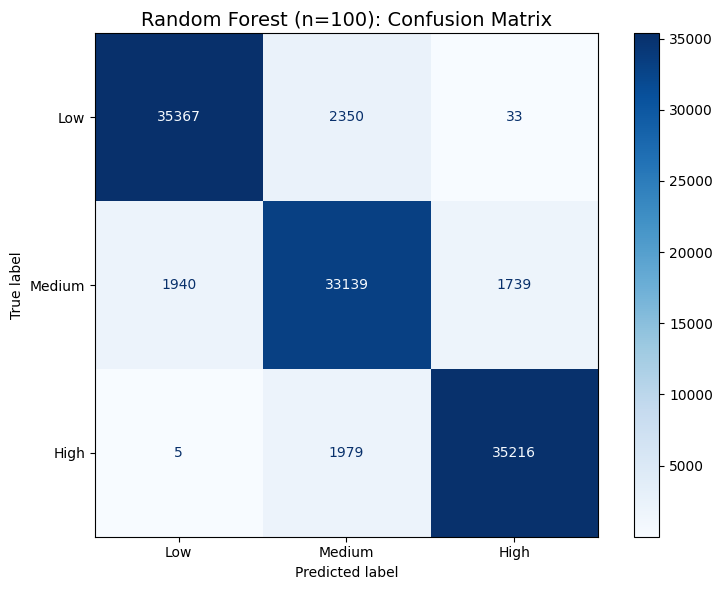

 Confusion matrix saved to: /kaggle/working/results/cm_best_model.png


In [15]:
# Plot confusion matrix for the best model
from sklearn.metrics import ConfusionMatrixDisplay

# Map model names to model objects
models_map = {
    'Logistic Regression': model_lr,
    'KNN Classifier (k=5)': model_knn,
    'Decision Tree (max_depth=20)': model_dt,
    'Random Forest (n=100)': model_rf,
    'Naive Bayes': model_nb,
    'Gradient Boosting (n=100)': model_gb
}

# Get best model
best_model_name = results_df.iloc[0]['Model']
best_model = models_map[best_model_name]

# Get predictions
y_pred_best = best_model.predict(trainer.X_test)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    trainer.y_test, y_pred_best,
    display_labels=trainer.class_names,  # ← Changed from display_names
    ax=ax,
    cmap='Blues'
)
ax.set_title(f'{best_model_name}: Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/results/cm_best_model.png', dpi=160)
plt.show()
print(" Confusion matrix saved to: /kaggle/working/results/cm_best_model.png")

## **Plot Model Comparison Bar Chart**

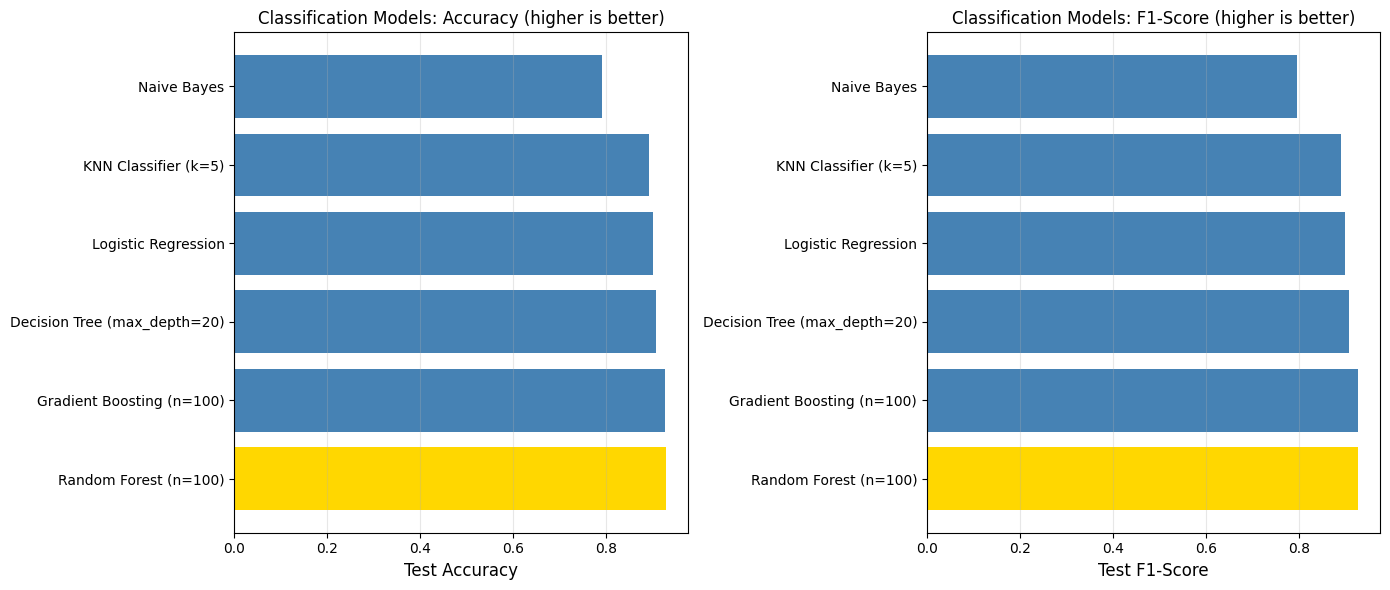

 Comparison chart saved!


In [12]:
#  Visual comparison of all classification models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Accuracy
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
axes[0].barh(results_df['Model'], results_df['Test Accuracy'], color=colors)
axes[0].set_xlabel('Test Accuracy', fontsize=12)
axes[0].set_title('Classification Models: Accuracy (higher is better)', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: F1-Score
axes[1].barh(results_df['Model'], results_df['Test F1-Score'], color=colors)
axes[1].set_xlabel('Test F1-Score', fontsize=12)
axes[1].set_title('Classification Models: F1-Score (higher is better)', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/kaggle/working/results/classification_model_comparison.png', dpi=150)
plt.show()
print(" Comparison chart saved!")

## **Feature Importance for Best Tree Model**

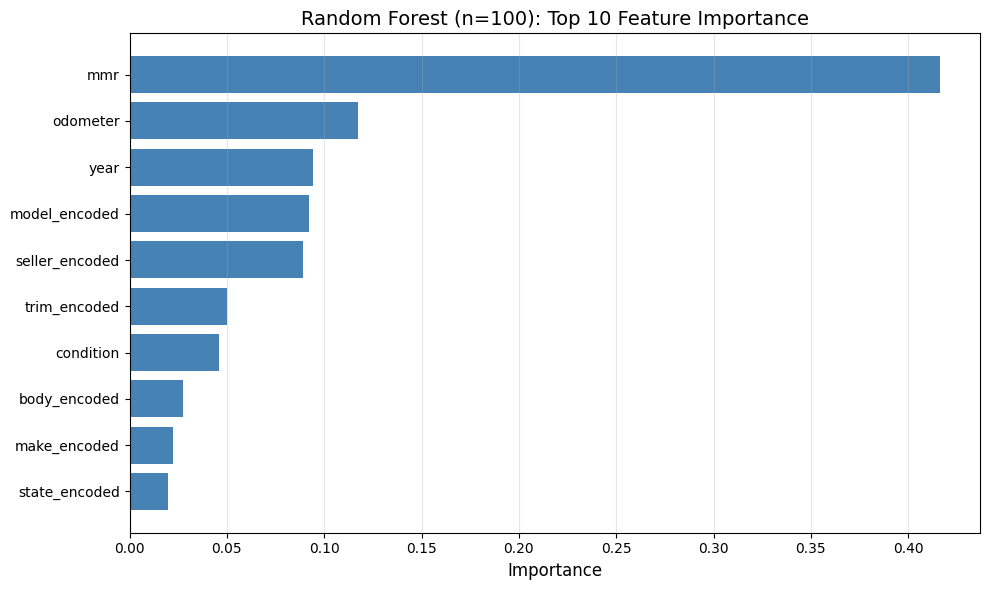

 Feature importance plot saved!

 Top 10 Features (Random Forest (n=100)):
   mmr: 0.4161
   odometer: 0.1171
   year: 0.0941
   model_encoded: 0.0923
   seller_encoded: 0.0889
   trim_encoded: 0.0501
   condition: 0.0457
   body_encoded: 0.0276
   make_encoded: 0.0222
   state_encoded: 0.0196


In [16]:
#  Feature importance for the best tree-based model
# Finding the best tree-based model (Random Forest, Decision Tree, or Gradient Boosting)
tree_models = {
    'Random Forest (n=100)': model_rf,
    'Decision Tree (max_depth=20)': model_dt,
    'Gradient Boosting (n=100)': model_gb
}

best_tree_model_name = None
best_tree_model = None
for name, model in tree_models.items():
    if name == best_model_name:
        best_tree_model_name = name
        best_tree_model = model
        break

if best_tree_model and hasattr(best_tree_model, 'feature_importances_'):
    importances = best_tree_model.feature_importances_
    feature_names = trainer.X_train.columns
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(10)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'{best_tree_model_name}: Top 10 Feature Importance', fontsize=14)
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('/kaggle/working/results/feature_importance_best_model.png', dpi=150)
    plt.show()
    print(" Feature importance plot saved!")
    
    print(f"\n Top 10 Features ({best_tree_model_name}):")
    for idx, row in importance_df.iterrows():
        print(f"   {row['feature']}: {row['importance']:.4f}")
else:
    print(f"Best model ({best_model_name}) is not a tree-based model or has no feature importance.")

## **Classification Report for Best Model**

In [14]:
# Display detailed classification report for best model
from sklearn.metrics import classification_report

print("="*60)
print(f" CLASSIFICATION REPORT - {best_model_name}")
print("="*60)

report = classification_report(trainer.y_test, y_pred_best, target_names=trainer.class_names)
print(report)

# Also show per-class metrics in a table
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    trainer.y_test, y_pred_best, average=None, labels=[0, 1, 2]
)

report_df = pd.DataFrame({
    'Class': ['Low (0)', 'Medium (1)', 'High (2)'],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})
print("\n Per-Class Metrics:")
print(report_df.to_string(index=False))

 CLASSIFICATION REPORT - Random Forest (n=100)
              precision    recall  f1-score   support

         Low       0.95      0.94      0.94     37750
      Medium       0.88      0.90      0.89     36818
        High       0.95      0.95      0.95     37200

    accuracy                           0.93    111768
   macro avg       0.93      0.93      0.93    111768
weighted avg       0.93      0.93      0.93    111768


 Per-Class Metrics:
     Class  Precision   Recall  F1-Score  Support
   Low (0)   0.947872 0.936874  0.942341    37750
Medium (1)   0.884461 0.900076  0.892200    36818
  High (2)   0.952093 0.946667  0.949372    37200
